# Brain Signal Analysis Pipeline (v3 | CM cluster → concat time series → BrainLM)

**v3 design**
- **CM**: used **only** for K-means clustering (segment grouping).
- **BrainLM input**: for each sliding window of `SEQ_LEN` segments **within the same CM cluster**, concatenate the **raw segment time series** along time → shape `(T_total, n_ROI)`.
- **One shared** time-series BrainLM (latents live in a **single** space → easier cluster comparison than v2 per-cluster CM models).
- Outputs under `visualization_ver3/` and `checkpoint/brainlm_v3/`.

Run cells top-to-bottom. Re-run segmentation only when needed (`REUSE_SEGMENT_CACHE=False`).

In [1]:
import logging
import os
import pickle
import sys
from pathlib import Path

os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

_cwd = Path.cwd().resolve()
for _p in [_cwd, _cwd / 'MTAD-GAT', _cwd.parent]:
    if (_p / 'pipeline').exists():
        sys.path.insert(0, str(_p))
        break

logging.basicConfig(level=logging.INFO)

# Torch thread limiting helps stability on macOS when mixing sklearn/numpy + torch.
try:
    torch.set_num_threads(1)
    torch.set_num_interop_threads(1)
except Exception:
    pass

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

ROOT = Path(sys.path[0])
DATA_PATH = ROOT / 'data' / 'DATA'
RESULT_PATH = ROOT / 'result'
SPLIT_DIR = ROOT / 'data' / 'DATA' / 'data_pre' / 'split_info'
OUTPUT_PATH = ROOT / 'visualization_ver3'
CHECKPOINT_PATH = ROOT / 'checkpoint' / 'brainlm_v3'
CACHE_PATH = CHECKPOINT_PATH / 'cache'

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
CACHE_PATH.mkdir(parents=True, exist_ok=True)

print('device:', device)
print('ROOT:', ROOT)

device: mps
ROOT: /Users/mac/Desktop/code/MTAD-GAT


In [2]:
# --- config ---
USE_FISHER_Z = True
OUTPUT_SUFFIX = 'z' if USE_FISHER_Z else 'r'

K = 4
SEQ_LEN = 4          # number of consecutive segments to concatenate
STRIDE = 1
VAL_SPLIT = 0.1
TEST_SPLIT = 0.1
MASK_RATIO = 0.15

MAX_TIME_PERCENTILE = 95.0
MAX_TIME_CAP = 2048
BATCH_SIZE = 8
MAX_EPOCHS = 40
LR = 1e-4
PATIENCE = 8

REUSE_SEGMENT_CACHE = True
SEGMENT_CACHE = CACHE_PATH / 'all_segments.pkl'

print('K=', K, 'SEQ_LEN=', SEQ_LEN, 'STRIDE=', STRIDE)

K= 4 SEQ_LEN= 4 STRIDE= 1


## 1. Segmentation

In [3]:
from pipeline.segmentation import segment_all_subjects, get_segment_statistics

SEGMENTATION_METHOD = 'embedding'
MTAD_GAT_CHECKPOINT = ROOT / 'checkpoint' / 'global_checkpoint_iter_0.pkl'

if REUSE_SEGMENT_CACHE and SEGMENT_CACHE.exists():
    with open(SEGMENT_CACHE, 'rb') as f:
        all_segments = pickle.load(f)
    print('Loaded cached segments:', SEGMENT_CACHE)
elif SEGMENTATION_METHOD == 'embedding':
    from pipeline.segmentation_evaluation import segment_all_subjects_embedding
    all_segments = segment_all_subjects_embedding(
        data_path=DATA_PATH,
        checkpoint_path=MTAD_GAT_CHECKPOINT,
        min_segment_len=30,
        window_size=64,
        split_dir=SPLIT_DIR,
        top_k=20,
        smooth_window=5,
        device=device,
        data_pre_path=SPLIT_DIR.parent,
        verbose=True,
    )
    with open(SEGMENT_CACHE, 'wb') as f:
        pickle.dump(all_segments, f)
    print('Saved segment cache:', SEGMENT_CACHE)
else:
    all_segments = segment_all_subjects(
        data_path=DATA_PATH,
        result_path=RESULT_PATH,
        min_segment_len=30,
        window_size=64,
        split_dir=SPLIT_DIR,
        method=SEGMENTATION_METHOD,
        smooth_window=5,
    )

segment_stats = get_segment_statistics(all_segments)
print(segment_stats['length'].describe())
print('Total segments:', len(segment_stats))

Loaded cached segments: /Users/mac/Desktop/code/MTAD-GAT/checkpoint/brainlm_v3/cache/all_segments.pkl
count    308.000000
mean     105.194805
std       83.675118
min       31.000000
25%       46.000000
50%       75.000000
75%      140.000000
max      549.000000
Name: length, dtype: float64
Total segments: 308


## 2. CM computation + clustering (CM not used for BrainLM training)

Subject 108828: 14 CMs computed
Subject 113316: 12 CMs computed
Subject 111211: 13 CMs computed
Subject 119025: 11 CMs computed
Subject 113215: 10 CMs computed
Subject 107018: 9 CMs computed
Subject 120717: 13 CMs computed
Subject 113619: 11 CMs computed
Subject 114419: 11 CMs computed
Subject 120515: 12 CMs computed
Subject 108121: 12 CMs computed
Subject 106319: 9 CMs computed
Subject 100307: 14 CMs computed
Subject 111716: 12 CMs computed
Subject 104416: 13 CMs computed
Subject 100408: 13 CMs computed
Subject 105014: 13 CMs computed
Subject 120111: 8 CMs computed
Subject 117122: 11 CMs computed
Subject 119732: 14 CMs computed
Subject 118831: 10 CMs computed
Subject 103818: 11 CMs computed
Subject 113922: 12 CMs computed
Subject 116524: 10 CMs computed
Subject 102816: 11 CMs computed
Subject 121416: 8 CMs computed
Subject 111514: 11 CMs computed
CM matrix shape: (100, 100)
Flat CM samples: (308, 4950)
Silhouette: 0.07756674289703369
Cluster sizes: {np.int32(0): np.int64(30), np.int32

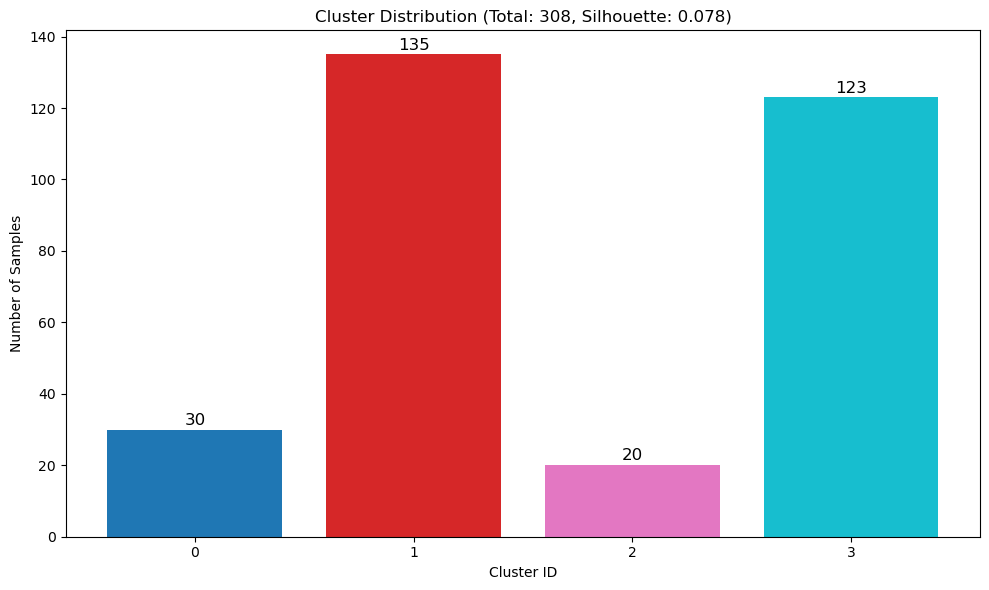

In [4]:
from pipeline.connectivity import compute_all_cms, collect_all_cms_flat
from pipeline.clustering import perform_clustering
from pipeline.visualization import plot_cluster_distribution

all_cms = compute_all_cms(
    all_segments,
    method='pearson',
    min_segment_len=10,
    use_fisher_z=USE_FISHER_Z,
)
X, cm_labels = collect_all_cms_flat(all_cms)
n_features = all_cms[list(all_cms.keys())[0]][0].n_features
print('CM matrix shape:', all_cms[list(all_cms.keys())[0]][0].matrix.shape)
print('Flat CM samples:', X.shape)

clustering_result = perform_clustering(
    X,
    cm_labels,
    n_clusters=K,
    standardize=True,
    use_minibatch=True,
    skip_silhouette=False,
)
print('Silhouette:', clustering_result.silhouette)
print('Cluster sizes:', clustering_result.get_cluster_sizes())

fig = plot_cluster_distribution(clustering_result, show=False)
fig.savefig(OUTPUT_PATH / f'cm_cluster_distribution_{OUTPUT_SUFFIX}.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Build concatenated time-series windows (per CM cluster)

In [5]:
from pipeline.v3_sequences import (
    build_ts_concat_sequences,
    count_by_cluster,
    split_examples,
    suggest_max_time_steps,
)

ts_examples = build_ts_concat_sequences(
    all_segments=all_segments,
    cm_labels_list=cm_labels,
    cluster_labels_flat=clustering_result.labels,
    seq_len=SEQ_LEN,
    stride=STRIDE,
)
print('Concat TS examples:', len(ts_examples))
print('Per cluster:', count_by_cluster(ts_examples))

train_ex, val_ex, test_ex = split_examples(
    ts_examples,
    val_split=VAL_SPLIT,
    test_split=TEST_SPLIT,
)
print('Train/Val/Test:', len(train_ex), len(val_ex), len(test_ex))

MAX_TIME_STEPS = suggest_max_time_steps(
    train_ex,
    percentile=MAX_TIME_PERCENTILE,
    absolute_cap=MAX_TIME_CAP,
)
print('MAX_TIME_STEPS (pad/truncate):', MAX_TIME_STEPS)

Concat TS examples: 83
Per cluster: {3: 28, 1: 54, 0: 1}
Train/Val/Test: 69 8 6
MAX_TIME_STEPS (pad/truncate): 670


## 4. Train shared time-series BrainLM

In [6]:
from brainlm.ts_dataset import FeatureNormalizer, create_ts_dataloaders
from brainlm.ts_model import BrainLMTimeSeriesConfig
from brainlm.ts_train import extract_ts_latents, train_brainlm_ts

normalizer = FeatureNormalizer().fit(train_ex)

train_loader, val_loader, test_loader = create_ts_dataloaders(
    train_ex,
    val_ex,
    test_ex,
    max_time_steps=MAX_TIME_STEPS,
    batch_size=BATCH_SIZE,
    mask_ratio=MASK_RATIO,
    normalizer=normalizer,
)

ts_config = BrainLMTimeSeriesConfig(
    n_features=n_features,
    d_model=256,
    nhead=8,
    num_encoder_layers=4,
    num_decoder_layers=2,
    max_time_steps=MAX_TIME_STEPS,
    mask_ratio=MASK_RATIO,
)

run_dir = CHECKPOINT_PATH / f'ts_concat_seq{SEQ_LEN}_st{STRIDE}_{OUTPUT_SUFFIX}'
run_dir.mkdir(parents=True, exist_ok=True)

model, history = train_brainlm_ts(
    train_loader=train_loader,
    val_loader=val_loader,
    config=ts_config,
    max_epochs=MAX_EPOCHS,
    lr=LR,
    patience=PATIENCE,
    checkpoint_dir=run_dir,
    device=device,
)

pd.DataFrame(history).to_csv(run_dir / 'training_history.csv', index=False)
with open(run_dir / 'normalizer.pkl', 'wb') as f:
    pickle.dump(normalizer, f)
print('Checkpoints:', run_dir)

/Users/mac/Desktop/code/MTAD-GAT/brainlm/ts_model.py:74: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=config.num_encoder_layers)
Epoch 21: 100%|██████████| 9/9 [00:02<00:00,  4.12it/s, loss=90.8645] 


Checkpoints: /Users/mac/Desktop/code/MTAD-GAT/checkpoint/brainlm_v3/ts_concat_seq4_st1_z


## 5. Extract latents (train + val + test, no masking)

Extracting latents: 100%|██████████| 11/11 [00:00<00:00, 11.24it/s]


Latents (train+val+test): (83, 256) [train=69, val=8, test=6]


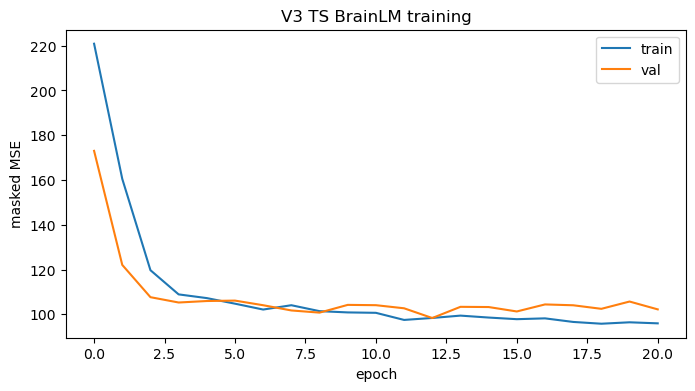

Figures saved to /Users/mac/Desktop/code/MTAD-GAT/visualization_ver3


In [7]:
from torch.utils.data import DataLoader

from brainlm.ts_dataset import TSConcatDataset
from brainlm.ts_train import extract_ts_latents

# v2와 동일: manifold/viz용 latent는 train + val + test (masking 없음)
all_ex = list(train_ex) + list(val_ex) + list(test_ex)
all_loader = DataLoader(
    TSConcatDataset(
        all_ex,
        max_time_steps=MAX_TIME_STEPS,
        mask_ratio=0.0,
        normalizer=normalizer,
        augment=False,
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

latents, cluster_ids, _ = extract_ts_latents(model, all_loader, device)
print(
    'Latents (train+val+test):',
    latents.shape,
    f'[train={len(train_ex)}, val={len(val_ex)}, test={len(test_ex)}]',
)

tag = f'seq{SEQ_LEN}_st{STRIDE}_{OUTPUT_SUFFIX}'
latent_compare_dir = OUTPUT_PATH / f'latent_compare_{tag}'
latent_compare_dir.mkdir(parents=True, exist_ok=True)

np.savez(
    run_dir / 'all_latents.npz',
    latents=latents,
    cluster_ids=cluster_ids,
    n_train=len(train_ex),
    n_val=len(val_ex),
    n_test=len(test_ex),
)

# cluster별 dict (시각화 셀에서 사용)
all_latents = {}
cluster_latents = {}
for cid in np.unique(cluster_ids):
    z = latents[cluster_ids == cid]
    all_latents[int(cid)] = z
    if z.shape[0] >= 2 and z.shape[1] >= 2:
        cluster_latents[int(cid)] = z
    else:
        print(f'[note] CM cluster {cid}: shape={z.shape} — profile plots only')

print('Saved latents:', run_dir / 'all_latents.npz')
print('Per-cluster shapes:')
for cid in sorted(all_latents):
    in_dimred = cid in cluster_latents
    print(f'  CM cluster {cid}: {all_latents[cid].shape}  -> dimred={"yes" if in_dimred else "profile only"}')

## 6. Summary table

In [8]:
rows = []
for cid in sorted(all_latents.keys()):
    z = all_latents[cid]
    rows.append({
        'cm_cluster': cid,
        'n_windows': z.shape[0],
        'latent_dim': z.shape[1],
        'mean_l2': float(np.linalg.norm(z, axis=1).mean()),
        'std_l2': float(np.linalg.norm(z, axis=1).std()),
    })
summary = pd.DataFrame(rows)
display(summary)
summary.to_csv(OUTPUT_PATH / f'latent_summary_{tag}.csv', index=False)

,cm_cluster,n_windows,latent_dim,mean_l2,std_l2
0,0,1,256,53.071789,0.000000
1,1,54,256,54.023491,0.881283
2,3,28,256,52.868141,0.788872


## 7. Latent comparison visualizations (v2-style)

CM cluster별 latent 분포·유사도·manifold를 v2와 동일한 패널로 시각화합니다.
v3는 **하나의 shared BrainLM** latent space이므로 pooled PCA/t-SNE는 클러스터 간 **직접 비교**에 사용할 수 있습니다.

`cluster_latents`는 per-cluster PCA/t-SNE에 **n≥2, dim≥2** 인 클러스터만 포함합니다.

In [2]:
# --- Latent comparison visualizations (v2-style) ---
# Run after section 5–6. Saves figures under latent_compare_dir/

from pathlib import Path

from pipeline.visualization import (
    visualize_latents,
    plot_latent_l2_norms_by_cluster,
    plot_pooled_latents_dimred,
    plot_per_cluster_pca_grid,
    plot_cluster_latent_mean_cosine_heatmap,
    plot_latent_scalar_stats_bars,
    plot_latent_pairwise_cosine_violin,
    plot_within_cluster_cosine_heatmaps,
    plot_latent_mean_vector_heatmap,
    plot_pca_explained_variance_per_cluster,
    plot_per_cluster_embedding_grid,
    plot_pooled_latents_methods_panel,
    plot_single_sample_latent_profiles,
    plot_training_history,
)

run_name = tag if 'tag' in globals() else f'seq{SEQ_LEN}_st{STRIDE}_{OUTPUT_SUFFIX}'
out_dir = (
    latent_compare_dir
    if 'latent_compare_dir' in globals()
    else OUTPUT_PATH / f'latent_compare_{run_name}'
)
out_dir = Path(out_dir)
out_dir.mkdir(parents=True, exist_ok=True)

# Reload from disk if section 5 was run in a previous session
if 'all_latents' not in globals() or not all_latents:
    npz_path = run_dir / 'all_latents.npz'
    if not npz_path.exists():
        raise FileNotFoundError(
            f'Missing {npz_path}\nRun section 5 (Extract latents) first.'
        )
    _data = np.load(npz_path)
    latents = _data['latents']
    cluster_ids = _data['cluster_ids']
    all_latents = {}
    cluster_latents = {}
    for cid in np.unique(cluster_ids):
        z = latents[cluster_ids == cid]
        all_latents[int(cid)] = z
        if z.shape[0] >= 2 and z.shape[1] >= 2:
            cluster_latents[int(cid)] = z
elif 'cluster_latents' not in globals() or not cluster_latents:
    cluster_latents = {
        cid: z
        for cid, z in all_latents.items()
        if z.ndim == 2 and z.shape[0] >= 2 and z.shape[1] >= 2
    }

if not all_latents:
    raise RuntimeError('No latent arrays found. Run section 5 first.')

print('Latent shapes (PCA/t-SNE need n>=2; profile bar if n==1):')
for cid in sorted(all_latents):
    lat = all_latents[cid]
    in_dimred = cid in cluster_latents
    print(
        f'  CM cluster {cid}: {lat.shape}  -> '
        f'dimred={"yes" if in_dimred else "profile/summary only"}'
    )


def _save(fig, name):
    p = out_dir / name
    fig.savefig(p, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print('Saved:', p)


# Training curve (shared BrainLM)
if 'history' in globals() and history:
    _save(
        plot_training_history(history, show=False),
        f'training_curve_{run_name}.png',
    )

# Pooled manifold — all examples, colored by CM cluster (shared latent space)
if 'latents' in globals() and 'cluster_ids' in globals():
    for method in ('pca', 'tsne'):
        _save(
            visualize_latents(
                latents,
                cluster_ids,
                method=method,
                title=f'V3 pooled latents ({method.upper()}) | {run_name}',
                show=False,
            ),
            f'latent_pooled_{method}_{run_name}.png',
        )

# A) Cross-cluster scalar summaries
_save(
    plot_latent_scalar_stats_bars(
        all_latents, title=f'Summary stats | {run_name}', show=False
    ),
    f'latent_scalar_stats_{run_name}.png',
)
_save(
    plot_latent_l2_norms_by_cluster(
        all_latents, title=f'L2 norms | {run_name}', show=False
    ),
    f'latent_norms_violin_{run_name}.png',
)
if cluster_latents:
    _save(
        plot_latent_pairwise_cosine_violin(
            cluster_latents,
            title=f'Within-cluster cosine | {run_name}',
            show=False,
        ),
        f'latent_pairwise_cosine_violin_{run_name}.png',
    )

# B) Per-cluster geometry
if cluster_latents:
    _save(
        plot_per_cluster_pca_grid(cluster_latents, n_cols=2, show=False),
        f'latent_pca_grid_{run_name}.png',
    )
    _save(
        plot_per_cluster_embedding_grid(
            cluster_latents, method='tsne', min_samples=5, n_cols=2, show=False
        ),
        f'latent_tsne_grid_{run_name}.png',
    )
    _save(
        plot_pca_explained_variance_per_cluster(cluster_latents, show=False),
        f'latent_pca_variance_{run_name}.png',
    )
    _save(
        plot_within_cluster_cosine_heatmaps(
            cluster_latents, min_samples=3, show=False
        ),
        f'latent_within_cosine_heatmaps_{run_name}.png',
    )
    for cid, lat in sorted(cluster_latents.items()):
        labels = np.full((lat.shape[0],), cid, dtype=np.int64)
        for method in ('pca', 'tsne'):
            _save(
                visualize_latents(
                    lat,
                    labels,
                    method=method,
                    title=f'{method.upper()} | {run_name} | CM cluster {cid}',
                    show=False,
                ),
                f'latent_{method}_{run_name}_cluster{cid}.png',
            )

# C) Mean-vector / cross-cluster
if len(all_latents) >= 2:
    _save(
        plot_latent_mean_vector_heatmap(all_latents, max_dims=48, show=False),
        f'latent_mean_vector_heatmap_{run_name}.png',
    )
    _save(
        plot_cluster_latent_mean_cosine_heatmap(all_latents, show=False),
        f'latent_mean_cosine_heatmap_{run_name}.png',
    )
if cluster_latents:
    _save(
        plot_pooled_latents_methods_panel(
            cluster_latents, methods=('pca', 'tsne', 'umap'), show=False
        ),
        f'latent_pooled_methods_panel_{run_name}.png',
    )
    _save(
        plot_pooled_latents_dimred(
            cluster_latents,
            method='pca',
            title=f'Pooled PCA | {run_name}',
            show=False,
        ),
        f'latent_pooled_pca_{run_name}.png',
    )

# D) Single-sample clusters (n=1)
_save(
    plot_single_sample_latent_profiles(all_latents, show=False),
    f'latent_single_sample_profiles_{run_name}.png',
)

print('Done. Latent comparison figures:', out_dir)


ModuleNotFoundError: No module named 'pipeline'

In [10]:
# --- Cross-cluster latent comparison (Are CM clusters different?) ---
# v3: one shared BrainLM => pooled PCA/t-SNE are in a **comparable** latent space.

from pathlib import Path

from pipeline.visualization import (
    plot_cluster_latent_mean_cosine_heatmap,
    plot_pooled_latents_dimred,
    plot_latent_mean_vector_heatmap,
)

run_name = tag if 'tag' in globals() else f'seq{SEQ_LEN}_st{STRIDE}_{OUTPUT_SUFFIX}'

if 'all_latents' in globals() and isinstance(all_latents, dict) and len(all_latents) > 0:
    _all_latents = all_latents
    _out_base = (
        latent_compare_dir
        if 'latent_compare_dir' in globals()
        else OUTPUT_PATH / f'latent_compare_{run_name}'
    )
elif (run_dir / 'all_latents.npz').exists():
    _data = np.load(run_dir / 'all_latents.npz')
    _lat = _data['latents']
    _cids = _data['cluster_ids']
    _all_latents = {
        int(cid): _lat[_cids == cid] for cid in np.unique(_cids)
    }
    _out_base = OUTPUT_PATH / f'latent_compare_{run_name}'
else:
    raise FileNotFoundError('Run section 5 first (all_latents.npz missing).')

if len(_all_latents) < 2:
    raise RuntimeError('Need latents for >=2 CM clusters.')

_dimred_latents = {
    cid: z
    for cid, z in _all_latents.items()
    if z.ndim == 2 and z.shape[0] >= 2 and z.shape[1] >= 2
}
_out_dir = Path(_out_base) / 'cross_cluster'
_out_dir.mkdir(parents=True, exist_ok=True)

print('=' * 60)
print('Cross-cluster comparison |', run_name)
print('Latent source: train+val+test (shared TS BrainLM)')
print('Shapes:')
for cid in sorted(_all_latents):
    print(f'  CM cluster {cid}: {_all_latents[cid].shape}')
print('=' * 60)

# Numeric: pairwise cosine of mean latent vectors
cids = sorted(_all_latents.keys())
means = []
for cid in cids:
    m = np.asarray(_all_latents[cid], dtype=np.float64).mean(axis=0)
    m = m / (np.linalg.norm(m) + 1e-12)
    means.append(m)
M = np.stack(means, axis=0)
sim = M @ M.T
df_sim = pd.DataFrame(
    sim, index=[f'CM{c}' for c in cids], columns=[f'CM{c}' for c in cids]
)
print('\nMean latent cosine similarity (1=same direction, 0=orthogonal):')
display(df_sim.round(3))


def _save(fig, name):
    p = _out_dir / name
    fig.savefig(p, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print('Saved:', p)


_save(
    plot_cluster_latent_mean_cosine_heatmap(
        _all_latents,
        title=f'Mean latent cosine across CM clusters | {run_name}',
        show=False,
    ),
    f'cross_cluster_mean_cosine_{run_name}.png',
)
_save(
    plot_latent_mean_vector_heatmap(
        _all_latents,
        max_dims=48,
        title=f'Mean latent profiles (top variance dims) | {run_name}',
        show=False,
    ),
    f'cross_cluster_mean_profile_{run_name}.png',
)

if len(_dimred_latents) >= 2:
    _save(
        plot_pooled_latents_dimred(
            _dimred_latents,
            method='pca',
            l2_normalize=True,
            title=f'Pooled PCA (L2-norm) | {run_name}',
            show=False,
        ),
        f'cross_cluster_pooled_pca_{run_name}.png',
    )
    _save(
        plot_pooled_latents_dimred(
            _dimred_latents,
            method='tsne',
            l2_normalize=True,
            title=f'Pooled t-SNE (L2-norm) | {run_name}',
            show=False,
        ),
        f'cross_cluster_pooled_tsne_{run_name}.png',
    )
else:
    print('[skip] pooled PCA/t-SNE: need >=2 sequences per cluster for dimred')

print('\nInterpretation (v3):')
print('  - Shared BrainLM => pooled plots compare clusters in the same latent space.')
print('  - Heatmap off-diagonal low  => cluster mean latents differ.')
print('  - Per-cluster PCA/t-SNE grids = geometry INSIDE each cluster (local axes).')
print('Done:', _out_dir)


Cross-cluster comparison | seq4_st1_z
Latent source: train+val+test (shared TS BrainLM)
Shapes:
  CM cluster 0: (1, 256)
  CM cluster 1: (54, 256)
  CM cluster 3: (28, 256)

Mean latent cosine similarity (1=same direction, 0=orthogonal):


,CM0,CM1,CM3
CM0,1.000,0.960,0.989
CM1,0.960,1.000,0.974
CM3,0.989,0.974,1.000


Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver3/latent_compare_seq4_st1_z/cross_cluster/cross_cluster_mean_cosine_seq4_st1_z.png
Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver3/latent_compare_seq4_st1_z/cross_cluster/cross_cluster_mean_profile_seq4_st1_z.png
Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver3/latent_compare_seq4_st1_z/cross_cluster/cross_cluster_pooled_pca_seq4_st1_z.png
Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver3/latent_compare_seq4_st1_z/cross_cluster/cross_cluster_pooled_tsne_seq4_st1_z.png

Interpretation (v3):
  - Shared BrainLM => pooled plots compare clusters in the same latent space.
  - Heatmap off-diagonal low  => cluster mean latents differ.
  - Per-cluster PCA/t-SNE grids = geometry INSIDE each cluster (local axes).
Done: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver3/latent_compare_seq4_st1_z/cross_cluster
